In [1]:
# Imports used throughout
import os, json
import requests
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

# Create a folder to save JSON responses (matches the lecture style)
os.makedirs("json_files", exist_ok=True)

# OpenAlex endpoint base
BASE = "https://api.openalex.org/works"

# Use a REAL email. OpenAlex strongly prefers contact info; some networks block without it.
MAILTO = "jeremy.anderson@emory.edu"

# Add a clear User-Agent with your contact to avoid 403s
HEADERS = {
    "Accept": "application/json",
    "User-Agent": f"datasci530-assignment (mailto:{MAILTO})"
}

# A utility to pretty-save any JSON we download (handy for debugging)
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


In [ ]:
# Build the URL exactly like in lecture (long string on multiple lines with \ )
# Here we search TITLES only, exact phrase in quotes, and request just 1 item per page
# because we'll read the total count from meta.count.
url_q1 = \
    (f"{BASE}"
     f"?filter=title.search:%22artificial%20intelligence%22"   # title.search:"artificial intelligence"
     f"&per-page=1"                                            # tiny page; meta.count holds the total
     f"&mailto={MAILTO}"                                       # polite pool
    )

# Request the JSON (include headers to avoid 403s)
q1_json = requests.get(url_q1, headers=HEADERS, timeout=60).json()

# Optional: save the raw JSON to disk for readability / grading
save_json(q1_json, "json_files/q1_ai_title_count.json")

# Read the total number of matches from meta.count
q1_count = q1_json["meta"]["count"]
print(f'Exact-phrase count (TITLE contains "artificial intelligence"): {q1_count:,}')


# There are 195,860 works with "artificial intelligence" in the title.

Exact-phrase count (TITLE contains "artificial intelligence"): 195,860


In [ ]:
# We use OpenAlex server-side grouping:
# group_by=authorships.institutions.country_code
year_end = datetime.now().year

url_q2 = \
    (f"{BASE}"
     f"?filter=title.search:%22artificial%20intelligence%22,"   # exact phrase in title
     f"publication_year:2020-{year_end}"                        # years since 2020
     f"&group_by=authorships.institutions.country_code"         # group by author affiliation country
     f"&per-page=200"                                           # enough to get all countries in one response
     f"&sort=count:desc"                                        # sort by count descending
     f"&mailto={MAILTO}"
    )

q2_json = requests.get(url_q2, headers=HEADERS, timeout=60).json()
save_json(q2_json, "json_files/q2_group_by_country.json")

# Convert the group_by results (list of {key: <country_code>, count: <n>}) into a DataFrame
gb = pd.DataFrame(q2_json["group_by"]).rename(columns={"key": "country_code", "count": "n"})

# Clean up: drop missing/blank codes, add share column, sort
gb = gb[gb["country_code"].notna() & (gb["country_code"] != "")]
gb["share"] = gb["n"] / gb["n"].sum()
gb = gb.sort_values("n", ascending=False).reset_index(drop=True)

# (Optional) map country codes to names if you have pycountry installed
try:
    import pycountry
    def code_to_name(code):
        c = pycountry.countries.get(alpha_2=code)
        return c.name if c else code
    gb["country"] = gb["country_code"].map(code_to_name)
    gb = gb[["country_code", "country", "n", "share"]]
except Exception:
    pass

gb.head(20)  # show the top 20 countries

## Table for Question 2 below 


,country_code,key_display_name,n,share
0,https://openalex.org/countries/US,United States of America,20010,0.154340
1,https://openalex.org/countries/CN,China,15627,0.120533
2,https://openalex.org/countries/IN,India,11074,0.085415
3,https://openalex.org/countries/GB,United Kingdom of Great Britain and Northern I...,6739,0.051979
4,https://openalex.org/countries/IT,Italy,4102,0.031639
5,https://openalex.org/countries/DE,Germany,3926,0.030282
6,https://openalex.org/countries/CA,Canada,3421,0.026387
7,https://openalex.org/countries/AU,Australia,2926,0.022569
8,https://openalex.org/countries/TR,Turkey,2874,0.022168
9,https://openalex.org/countries/ES,Spain,2837,0.021882


In [ ]:
# We'll request the top 10 by citations. To be robust against 403s,
# we won't use 'select' (smaller responses) on the first try; OpenAlex returns all fields by default.

url_q3 = \
    (f"{BASE}"
     f"?filter=title.search:%22artificial%20intelligence%22,"
     f"publication_year:2020-{year_end}"
     f"&sort=cited_by_count:desc"
     f"&per-page=10"
     f"&mailto={MAILTO}"
    )

q3_json = requests.get(url_q3, headers=HEADERS, timeout=60).json()
save_json(q3_json, "json_files/q3_top10_most_cited.json")

# Flatten the JSON for the table you need
rows = []
for w in q3_json.get("results", []):
    title = w.get("display_name")
    year  = w.get("publication_year")
    cites = w.get("cited_by_count")

    # collect authors and institutions across all authorships
    authors, insts = [], []
    for auth in w.get("authorships", []):
        a = (auth.get("author") or {}).get("display_name")
        if a:
            authors.append(a)
        for inst in auth.get("institutions", []):
            dn = inst.get("display_name")
            if dn:
                insts.append(dn)

    # de-duplicate institutions while preserving first appearance order
    seen = set()
    insts_unique = [x for x in insts if not (x in seen or seen.add(x))]

    rows.append({
        "title": title,
        "year": year,
        "cited_by_count": cites,
        "authors": ", ".join(authors),
        "institutions": ", ".join(insts_unique)
    })

top10 = pd.DataFrame(rows).sort_values("cited_by_count", ascending=False).reset_index(drop=True)
top10
# ##The titles of the names of the 10 most highly cited papers with "artificial intelligence" in the title published since 2020 are in the table below. 
# The citations range between 1,385 amd 2,249.
# All of the authors are associated with universities. 



,title,year,cited_by_count,authors,institutions
0,Artificial Intelligence in Education: A Review,2020,2249,"Lijia Chen, Pingping Chen, Zhijian Lin","Yango University, Fuzhou University"
1,The role of artificial intelligence in achievi...,2020,2195,"Ricardo Vinuesa, Hossein Azizpour, Iolanda Lei...","Swedish e-Science Research Centre, KTH Royal I..."
2,Using Artificial Intelligence to Detect COVID-...,2020,1956,"Lin Li, Lixin Qin, Zeguo Xu, Youbing Yin, Xin ...","Jianghan University, Wuhan Pulmonary Hospital,..."
3,Revolutionizing healthcare: the role of artifi...,2023,1629,"Shuroug A. Alowais, Sahar S. Alghamdi, Nada Al...",King Saud bin Abdulaziz University for Health ...
4,Comparing Physician and Artificial Intelligenc...,2023,1576,"John W. Ayers, Adam Poliak, Mark Dredze, Eric ...","University of California, San Diego, Qualcomm ..."
5,A Survey on Explainable Artificial Intelligenc...,2020,1560,"Erico Tjoa, Cuntai Guan","Alibaba Group (China), Nanyang Technological U..."
6,Artificial Intelligence (AI) applications for ...,2020,1414,"Raju Vaishya, Mohd Javaid, Ibrahim Haleem Khan...","Indraprastha Apollo Hospitals, Jamia Millia Is..."
7,Human Trust in Artificial Intelligence: Review...,2020,1405,"Ella Glikson, Anita Williams Woolley","Bar-Ilan University, Carnegie Mellon University"
8,Review of Artificial Intelligence Techniques i...,2020,1396,"Feng Shi, Jun Wang, Jun Shi, Ziyan Wu, Qian Wa...","United Imaging Healthcare (China), Shanghai Un..."
9,Photonics for artificial intelligence and neur...,2021,1385,"Bhavin J. Shastri, Alexander N. Tait, Thomas F...","Queen's University, Princeton University, Univ..."


term,GPT,LLM,artificial intelligence
year,,,
2016,34,60,1255
2017,24,33,2133
2018,36,63,4648
2019,41,38,8041
2020,84,56,12762
2021,138,25,16455
2022,212,49,19018
2023,1762,1631,29438
2024,2491,10201,45823


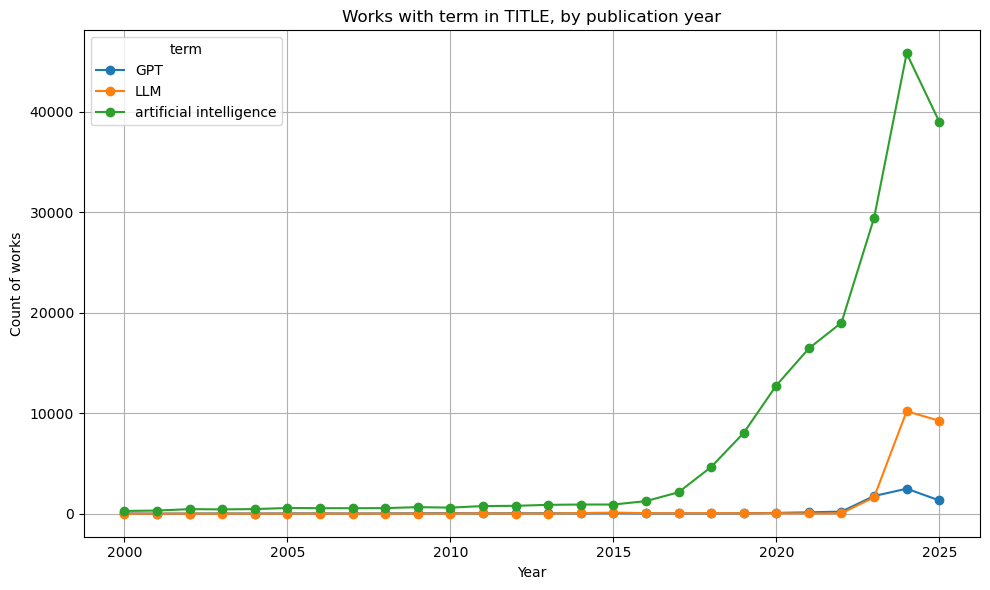

In [5]:
# Helper: fetch year-by-year counts for a TERM in the TITLE
def yearly_counts_title(term, quoted=True, y0=2000, y1=None):
    """
    Return a (year, n, term) DataFrame for works whose TITLE matches `term`.
    If quoted=True, match the exact token/phrase; if False, match words anywhere.
    """
    if y1 is None:
        y1 = datetime.now().year
    # Build title filter; quotes enforce exact phrase/token
    title_filter = f'%22{term.replace(" ", "%20")}%22' if quoted else term.replace(" ", "%20")
    url = (
        f"{BASE}"
        f"?filter=title.search:{title_filter},publication_year:{y0}-{y1}"
        f"&group_by=publication_year"
        f"&per-page=200"
        f"&sort=key:asc"
        f"&mailto={MAILTO}"
    )
    js = requests.get(url, headers=HEADERS, timeout=60).json()
    save_json(js, f"json_files/q4_{term.replace(' ','_')}_by_year.json")
    df = pd.DataFrame(js.get("group_by", [])).rename(columns={"key":"year","count":"n"})
    if not df.empty:
        df["year"] = df["year"].astype(int)
        df["n"]    = df["n"].astype(int)
        df["term"] = term
    return df

# Get series for each term (quoted=True = exact tokens; avoids picking up non-AI uses)
ai  = yearly_counts_title("artificial intelligence", quoted=True, y0=2000, y1=year_end)
llm = yearly_counts_title("LLM", quoted=True, y0=2000, y1=year_end)  # note: quoted avoids "Master of Laws" spills somewhat
gpt = yearly_counts_title("GPT", quoted=True, y0=2000, y1=year_end)  # "GPT" can still have biomedical meanings

# Combine and pivot to a year × term wide table
all_series = pd.concat([ai, llm, gpt], ignore_index=True)
trend = all_series.pivot(index="year", columns="term", values="n").fillna(0).astype(int)

# Show last few years in the table
display(trend.tail(10))

# Plot
ax = trend.plot(figsize=(10,6), marker="o")
ax.set_title("Works with term in TITLE, by publication year")
ax.set_xlabel("Year")
ax.set_ylabel("Count of works")
ax.grid(True)
plt.tight_layout()
plt.show()

# Optional: trend.to_csv("yearly_counts_ai_llm_gpt.csv")


,year,key_display_name,n,term
5,2016,2016,10,Sports Analytics
6,2017,2017,12,Sports Analytics
7,2018,2018,23,Sports Analytics
8,2019,2019,36,Sports Analytics
9,2020,2020,17,Sports Analytics
10,2021,2021,12,Sports Analytics
11,2022,2022,19,Sports Analytics
12,2023,2023,22,Sports Analytics
13,2024,2024,47,Sports Analytics
14,2025,2025,29,Sports Analytics


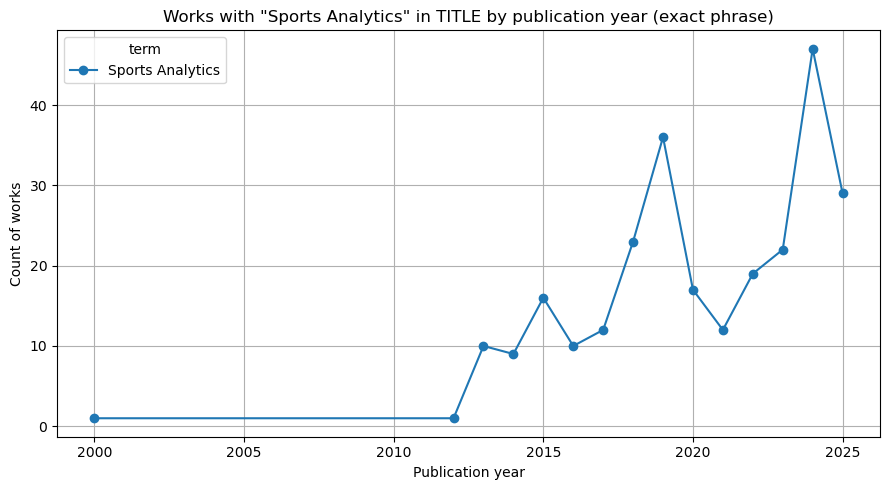

In [6]:
# --- Imports (used for the request, table, and plot) ---
import requests                 # HTTP calls to OpenAlex
import pandas as pd             # tidy tables
import matplotlib.pyplot as plt # simple plotting
from datetime import datetime   # current year for the range

# --- Reuse your earlier constants (define if you haven't already) ---
BASE   = "https://api.openalex.org/works"           # Works endpoint
MAILTO = "jeremy.anderson@emory.edu"               # <-- put YOUR real email
HEADERS = {                                         # explicit headers help avoid 403s
    "Accept": "application/json",
    "User-Agent": f"datasci530-hw (mailto:{MAILTO})"
}

YEAR_START = 2000                  # start year for the analysis window
YEAR_END   = datetime.now().year   # end at current year (updates automatically)

# === Choose your NEW keyword here ===
NEW_TERM = "Sports Analytics"   # <-- change to anything you want

# If you want exact phrase matching in TITLES, keep quoted=True.
# Set quoted=False to match titles that contain the words anywhere (broader, noisier).
QUOTED = True

# --- Helper: fetch year-by-year counts for a TITLE term from OpenAlex ---
def yearly_counts_for_title(term, quoted=True, y0=YEAR_START, y1=YEAR_END):
    """
    Returns a DataFrame with columns [year, n, term] for works whose TITLE matches `term`
    between years y0..y1 (inclusive), using server-side group_by=publication_year.
    quoted=True -> exact phrase (e.g., "reinforcement learning")
    quoted=False -> broader token match (words anywhere in the title)
    """
    # Build the title filter (OpenAlex is case-insensitive; quotes enforce exact phrase)
    title_filter = f'title.search:"{term}"' if quoted else f"title.search:{term}"

    # Compose query params (comma = logical AND for filters in OpenAlex)
    params = {
        "filter": f"{title_filter},publication_year:{y0}-{y1}",
        "group_by": "publication_year",   # return one row per year with a 'count'
        "per-page": 200,                  # enough to return all years at once
        "sort": "key:asc",                # order by the year key ascending
        "mailto": MAILTO
    }

    # Make the HTTP request
    r = requests.get(BASE, params=params, headers=HEADERS, timeout=60)
    r.raise_for_status()                  # raise an error if not 200 OK
    data = r.json()                       # parse JSON -> Python dict

    # Convert the grouped list ({key:year, count:n}) into a DataFrame
    df = pd.DataFrame(data.get("group_by", [])) \
           .rename(columns={"key": "year", "count": "n"})

    # Clean types & label with the searched term
    if not df.empty:
        df["year"] = df["year"].astype(int)
        df["n"]    = df["n"].astype(int)
        df["term"] = term
    return df

# --- Run the analysis for your NEW keyword ---
new_series = yearly_counts_for_title(NEW_TERM, quoted=QUOTED)

# Sanity check: show the last few years
display(new_series.tail(10))

# --- Pivot to wide (optional) and make a plot ---
# For a single series we can plot directly, but pivot keeps the pattern consistent.
wide = new_series.pivot(index="year", columns="term", values="n").fillna(0).astype(int)

# Plot the trend for your chosen term
ax = wide.plot(figsize=(9, 5), marker="o")
ax.set_title(f'Works with "{NEW_TERM}" in TITLE by publication year'
             + (" (exact phrase)" if QUOTED else " (broad match)"))
ax.set_xlabel("Publication year")
ax.set_ylabel("Count of works")
ax.grid(True)
plt.tight_layout()
plt.show()